# ZOMATO PROJECT DATA ANALYSIS

In [18]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#reading csv file
df = pd.read_csv(r"C:\Users\moham\Desktop\data analysis workshop\Zomato data .csv")

In [10]:
print(df)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

#Data cleaning

In [14]:
def new_rate(value):
    value=str(value).split('/')
    value = value[0];
    return float(value)

df['rate']=df['rate'].apply(new_rate)
df.head()
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [16]:
df.info() #non-null means no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of Restauraunt')

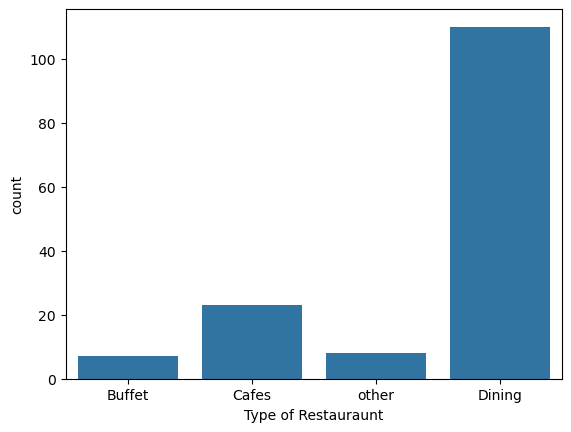

In [21]:
#1 what type of restaurant do customer order food more
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of Restauraunt")

Text(0, 0.5, 'votes')

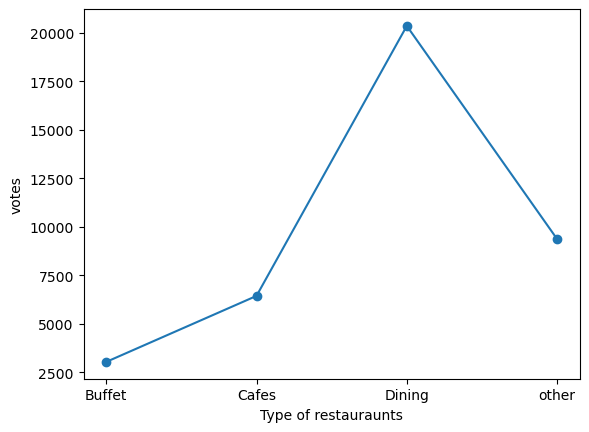

In [23]:
#2 how many votes does each type of restauraunts received 

group_data=df.groupby('listed_in(type)')['votes'].sum()
plt.plot(group_data,marker="o")
plt.xlabel("Type of restauraunts")
plt.ylabel("votes")

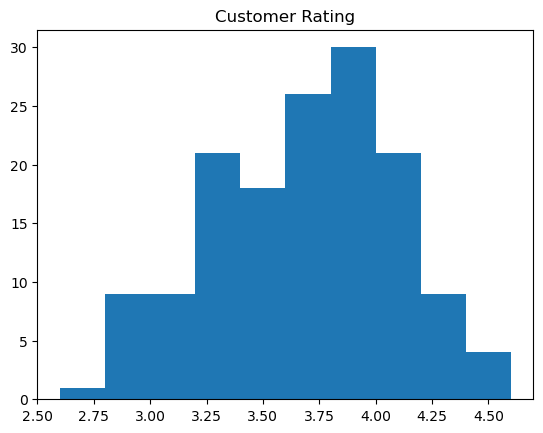

In [27]:
#3 what are the rating majority of customer has received 
plt.hist(df['rate'],bins=10)
plt.title("Customer Rating")
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

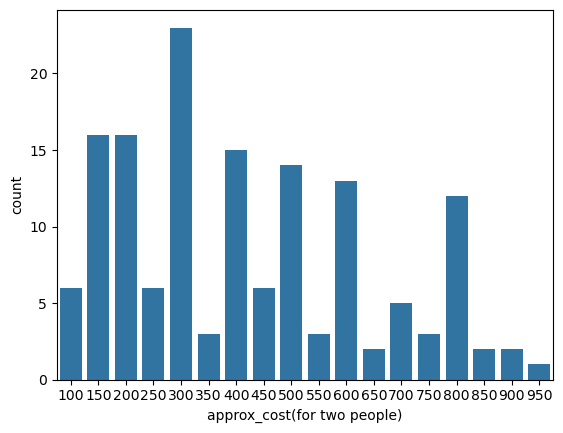

In [28]:
#4 what is the avg spending on each other for couples in zomato
couple_data=df["approx_cost(for two people)"]
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

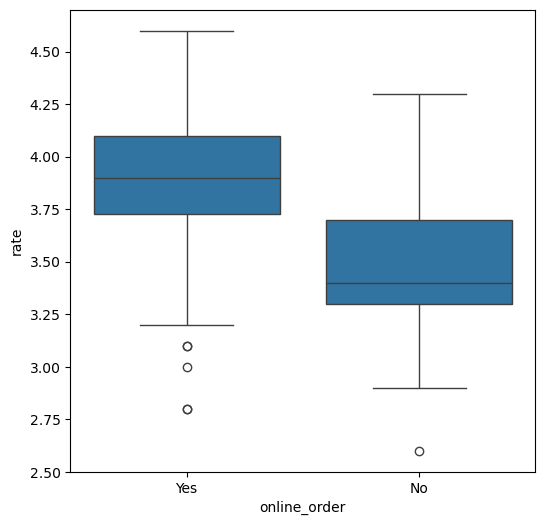

In [30]:
#5 which mode received the highest rating online or offline 
plt.figure(figsize = (6,6))
sns.boxplot(x="online_order" , y = "rate" ,data= df)

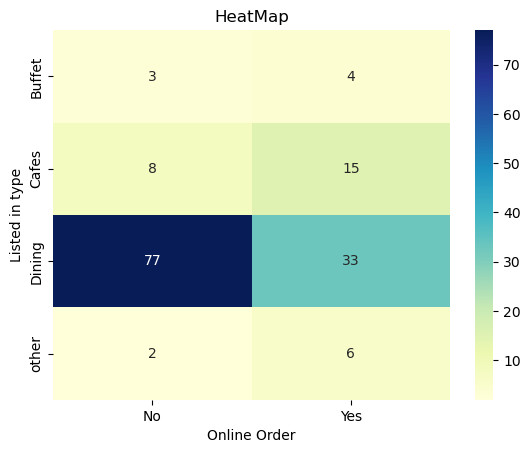

In [35]:
#6 which type of restaurant have more offline oreder so that zomato can give them good offers

pivot_table = df.pivot_table(index="listed_in(type)" , columns = "online_order" , aggfunc = "size" , fill_value=0)
sns.heatmap(pivot_table, annot=True , fmt='d' , cmap="YlGnBu")
plt.title("HeatMap")
plt.xlabel("Online Order")
plt.ylabel("Listed in type")
plt.show()